In [9]:
import matplotlib.pyplot as plt

import cobra

In [3]:
model = cobra.io.read_sbml_model("../../model.xml")

In [4]:
# To simulate the Na-powered flagella, add a reaction that imports Na+ into the cell, and force flux through it
new_rxn = cobra.Reaction("flagella_Na_import_c0")
new_rxn.name = "Flagella Na+ import"
new_rxn.add_metabolites({
    model.metabolites.cpd00971_e0: -1,
    model.metabolites.cpd00971_c0: 1
})
new_rxn


Reaction identifier,flagella_Na_import_c0
Name,Flagella Na+ import
Memory address,0x11a6ecd90
Stoichiometry,cpd00971_e0 --> cpd00971_c0 Na+ [e0] --> Na+
GPR,
Lower bound,0.0
Upper bound,1000.0


In [5]:
# Add the reaction to the model
model.add_reactions([new_rxn])

In [11]:
# Save the model to a json file for making Escher maps
cobra.io.save_json_model(model, "model_with_flagella.json")

In [6]:
# Define the minimal media composition
# There are protons and Na in the medium, beware
minimal_media = {
    # Potentially problematic ions
    "EX_cpd00971_e0": 1000,  # Na+_e0
    "EX_cpd00067_e0": 1000,  # H+_e0
    # C/N/O
    "EX_cpd00027_e0": 10,  # Glucose_e0
    "EX_cpd00013_e0": 1000,  # Ammonia
    "EX_cpd00007_e0": 1000,  # O2_e0
    # Other minerals
    "EX_cpd00058_e0": 1000,  # Cu2+_e0
    "EX_cpd00063_e0": 1000,  # Ca2+_e0
    "EX_cpd00048_e0": 1000,  # Sulfate_e0
    "EX_cpd10516_e0": 1000,  # fe3_e0
    "EX_cpd00254_e0": 1000,  # Mg_e0
    "EX_cpd00009_e0": 1000,  # Phosphate_e0
    "EX_cpd00205_e0": 1000,  # K+_e0
    "EX_cpd00099_e0": 1000,  # Cl-_e0
    "EX_cpd00030_e0": 1000,  # Mn2+_e0
    "EX_cpd00001_e0": 1000,  # H2O_e0
    "EX_cpd00034_e0": 1000,  # Zn2+_e0
    "EX_cpd00149_e0": 1000,  # Co2+_e0
}
# Set the medium
model.medium = minimal_media

In [7]:
growth_results = []
for lb in range(0, 110, 10):
    # Set the lower bound of the Na+ import reaction to force flux through it
    model.reactions.flagella_Na_import_c0.lower_bound = lb
    # Run pFBA
    sol = cobra.flux_analysis.pfba(model)
    # Save the growth rate
    growth_results.append(sol.fluxes['bio1_biomass'])
    # Save the fluxes to a JSON file
    sol.fluxes.to_json(f"fluxes_flagella_{lb}.json")

Text(0.5, 1.0, 'Effect of imposed flagella flux on growth rate')

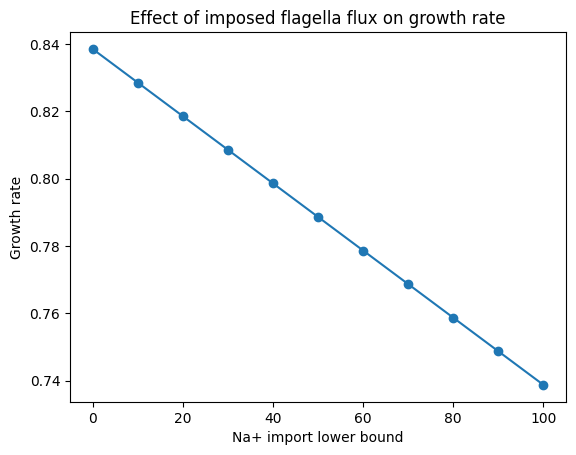

In [10]:
# Plot the growth results
plt.plot(range(0, 110, 10), growth_results, marker='o')
plt.xlabel("Na+ import lower bound")
plt.ylabel("Growth rate")
plt.title("Effect of imposed flagella flux on growth rate")